# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

C:\Users\santo\AppData\Local\Temp\ipykernel_2076\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\relational.py:300: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `d

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

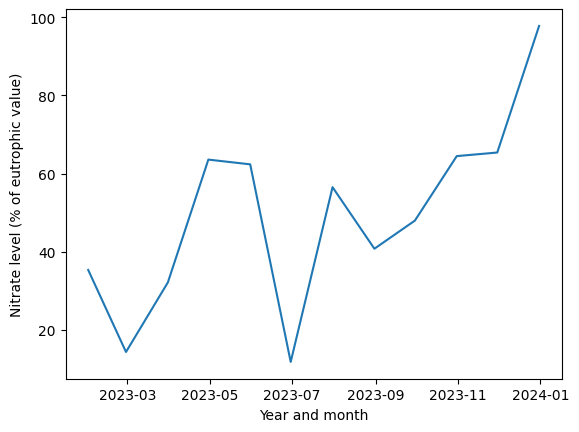

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\santo\AppData\Local\Temp\ipykernel_2076\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\relational.py:300: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `d

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

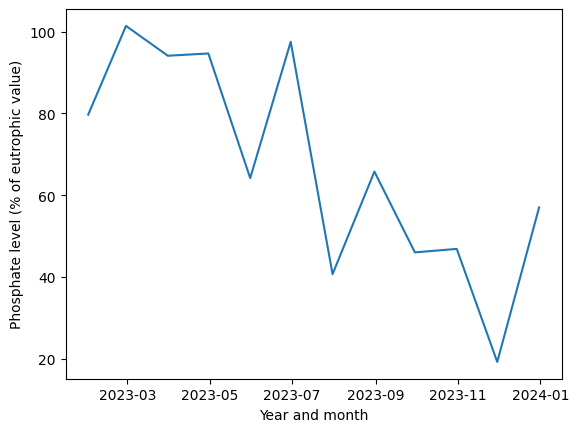

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

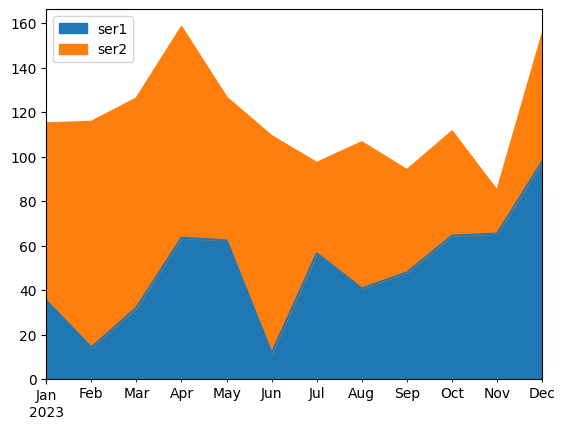

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

One main disadvantage of having the area plot is that it can be harder to read the individual trends and there is some clutter, such as the legend. Also in this senario, the legend of the area plot is not properly labeled, making it difficult to distinguish which series represents which chemical. Advantages of the area plot are that is it easier to see how much of both chemicals is within the water at any given point in the recorded year. 

I would change this to be a multi-line plot to be able to more clearly compare them and still see their independent behavior. I think it would also eliminate a lot of the visual clutter that comes with having an area plot. I find all the color to be a bit overwhelming. I would also add clear labels to the axes. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

                   Clicks  Impressions     Leads  Conversions  Conversion Rate
Clicks           1.000000     0.001500  0.054291     0.006728        -0.490762
Impressions      0.001500     1.000000 -0.035502    -0.013960         0.015196
Leads            0.054291    -0.035502  1.000000     0.023439        -0.014123
Conversions      0.006728    -0.013960  0.023439     1.000000         0.641099
Conversion Rate -0.490762     0.015196 -0.014123     0.641099         1.000000


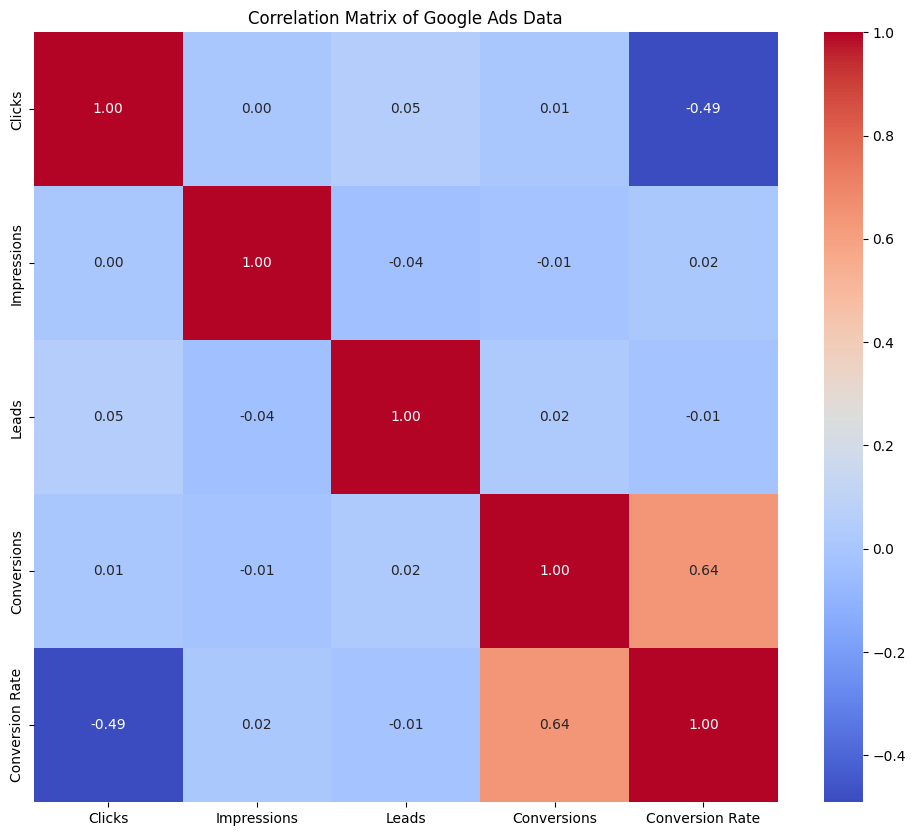

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv'
df_ads = pd.read_csv(file_path)

# Select only numeric columns for correlation
numeric_df = df_ads.select_dtypes(include=['number'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
print(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Google Ads Data')
plt.show()

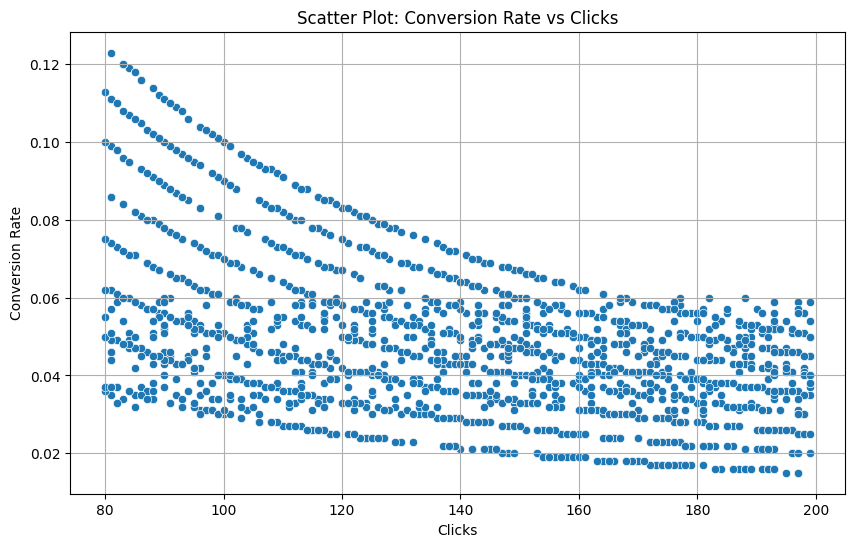

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ads, x='Clicks', y='Conversion Rate')
plt.title('Scatter Plot: Conversion Rate vs Clicks')
plt.xlabel('Clicks')
plt.ylabel('Conversion Rate')
plt.grid(True)
plt.show()

c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\categorical.py:128: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[self.orient] = ""
c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\

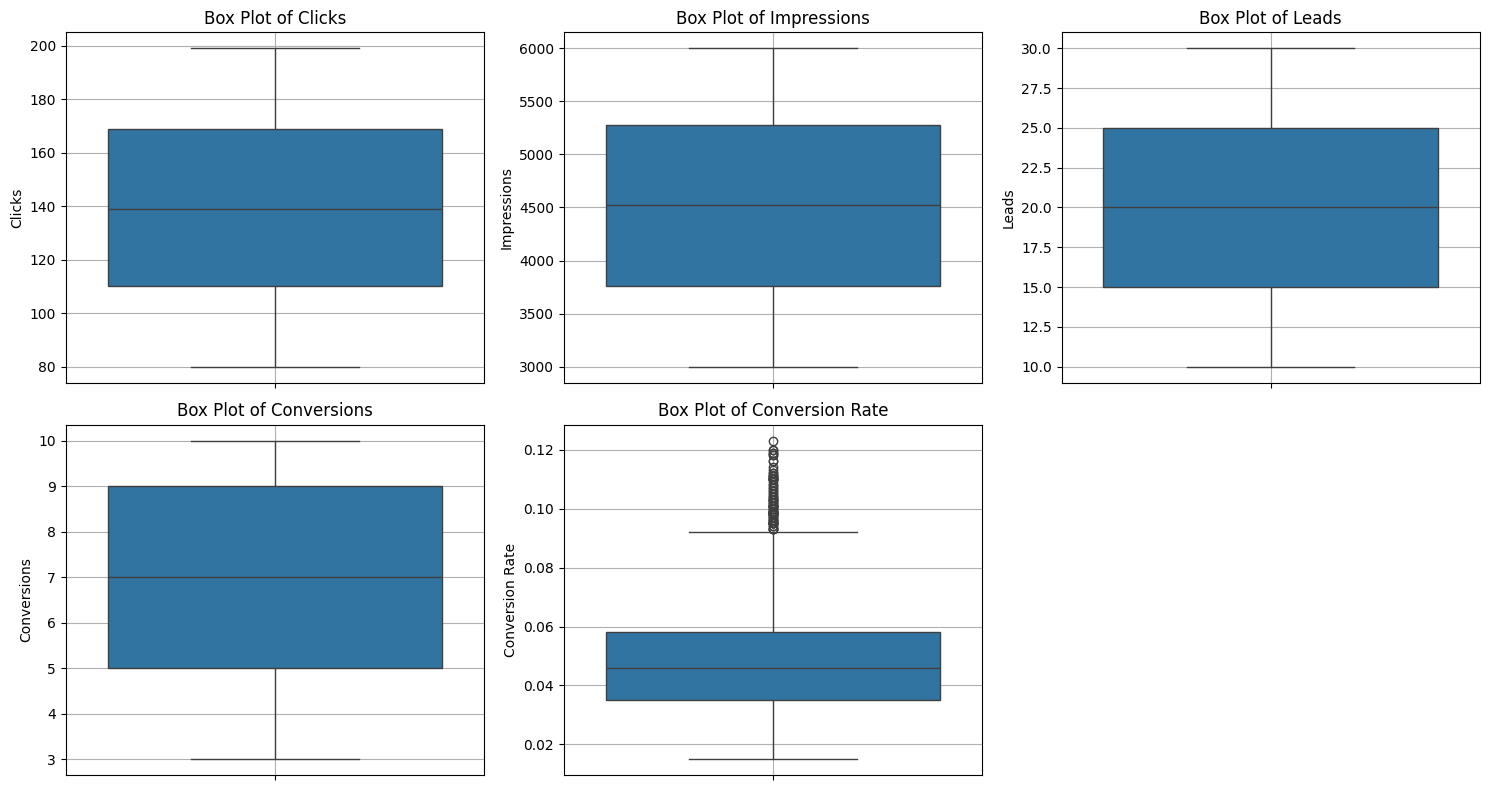

In [7]:
numeric_cols = numeric_df.columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_ads[col])
    plt.title(f'Box Plot of {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:

df_ads['Ad_Date'] = pd.to_datetime(df_ads['Ad_Date'], dayfirst=True, errors='coerce')

print(df_ads['Ad_Date'].head())
print(f"Any failed conversions (NaT)? {df_ads['Ad_Date'].isna().sum()}")

0   2024-11-16
1          NaT
2          NaT
3   2024-11-26
4   2024-11-22
Name: Ad_Date, dtype: datetime64[ns]
Any failed conversions (NaT)? 1707


C:\Users\santo\AppData\Local\Temp\ipykernel_2076\4261704972.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_ads['Ad_Date'] = pd.to_datetime(df_ads['Ad_Date'], dayfirst=True, errors='coerce')
C:\Users\santo\AppData\Local\Temp\ipykernel_2076\4261704972.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps

C:\Users\santo\AppData\Local\Temp\ipykernel_2076\481403807.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ads['Ad_Date'] = pd.to_datetime(df_ads['Ad_Date'], dayfirst=True, format='mixed')


Any failed conversions (NaT)? 0


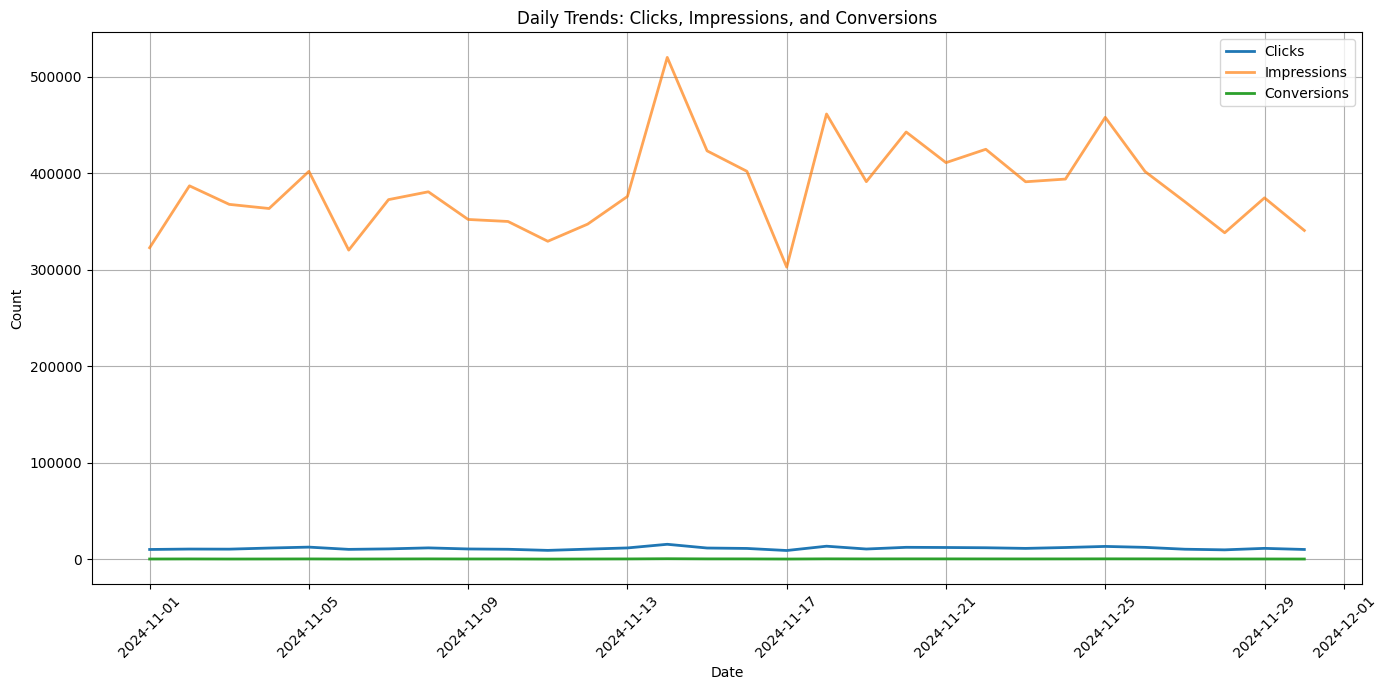

In [9]:
df_ads = pd.read_csv(file_path)

df_ads['Ad_Date'] = pd.to_datetime(df_ads['Ad_Date'], dayfirst=True, format='mixed')

print(f"Any failed conversions (NaT)? {df_ads['Ad_Date'].isna().sum()}")

daily_trends = df_ads.groupby('Ad_Date')[['Clicks', 'Impressions', 'Conversions']].sum().reset_index()

daily_trends = daily_trends.sort_values('Ad_Date')

plt.figure(figsize=(14, 7))
plt.plot(daily_trends['Ad_Date'], daily_trends['Clicks'], label='Clicks', linewidth=2)
plt.plot(daily_trends['Ad_Date'], daily_trends['Impressions'], label='Impressions', linewidth=2, alpha=0.7)
plt.plot(daily_trends['Ad_Date'], daily_trends['Conversions'], label='Conversions', linewidth=2)

plt.title('Daily Trends: Clicks, Impressions, and Conversions')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This data is not necessarily what I expected, except for the positive corrlation between Conversions and Conversion Rates. I believed that there would be a strong positive correlation between Leads and Clicks, my thought process being that more clicks would mean there are more leads generated. This case seems to be the opposite of what I thought, since there is a slight negative correlation between Clicks and Conversion Rate, indicating that those who are generating more digital traffic are not bringing greater engagement to the respective platform. There are no strong correlations between any of the data items of this dataset. Only Conversion Rates were found to contain outliers. I also do not find that the multiline plot brought any new insight. 

This Google Ads dataset was the third dataset that I used when completing this homework assignmen. I think I am having trouble picking the right datasets however, I have only been picking from the list of selected datasets for our projects. 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

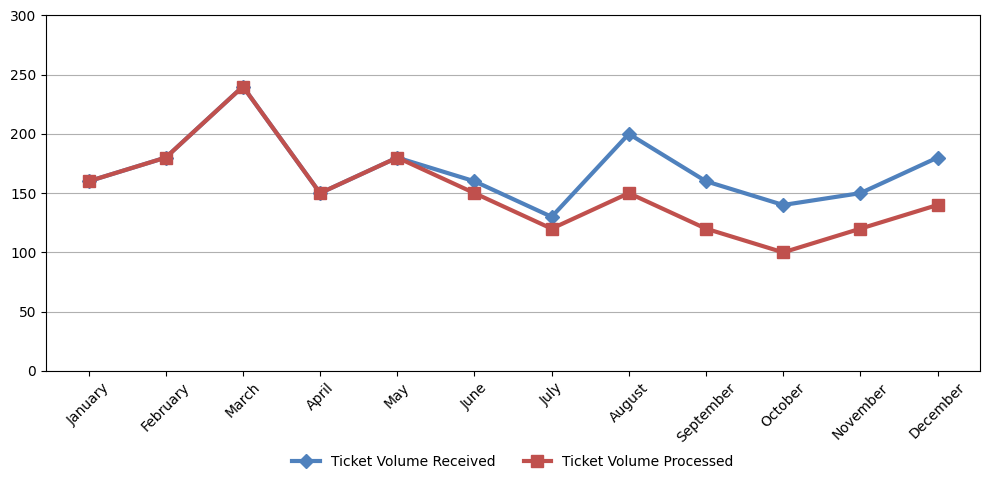

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Month': ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December'],
    'Ticket Volume Received': [160, 180, 240, 150, 180, 160, 130, 200, 160, 140, 150, 180],
    'Ticket Volume Processed': [160, 180, 240, 150, 180, 150, 120, 150, 120, 100, 120, 140]
}

df_tickets = pd.DataFrame(data)

plt.figure(figsize=(10, 5))

plt.plot(df_tickets['Month'], df_tickets['Ticket Volume Received'], 
         marker='D', color='#4F81BD', linewidth=3, label='Ticket Volume Received', markersize=7)

plt.plot(df_tickets['Month'], df_tickets['Ticket Volume Processed'], 
         marker='s', color='#C0504D', linewidth=3, label='Ticket Volume Processed', markersize=8)

plt.ylim(0, 300)
plt.ylabel('')
plt.xlabel('')
plt.title('') 
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

plt.tight_layout()

plt.show()